In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk

from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на GPT-2 Large

## Эксперимент 6: GPT-2 Large + depth-0

In [5]:
# Параметры эксперимента
VARIANT = "depth-0"
MODEL_SIZE = "gpt2-large"
BASE_MODEL_NAME = "gpt2-large"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 8

### Подготовка модели и данных

In [6]:
model, tokenizer = load_model_and_tokenizer(model_size=MODEL_SIZE, device="cuda")
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-large into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-35): 36 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_re

In [7]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [8]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 184 токенов (при макс длине 226)


In [9]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [10]:
MAX_LENGTH = max_p95

In [11]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [13]:
n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

In [14]:
n_layers

36

In [15]:
torch.cuda.empty_cache()

In [16]:
# Кэшируем активации
results = run_probing_experiment(
    model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:  69%|██████▉   | 25/36 [39:32<17:39, 96.34s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers:  72%|███████▏  | 26/36 [41:09<16:04, 96.42s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the con

In [39]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [41]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 22 (0-based), Dev Accuracy: 0.5220


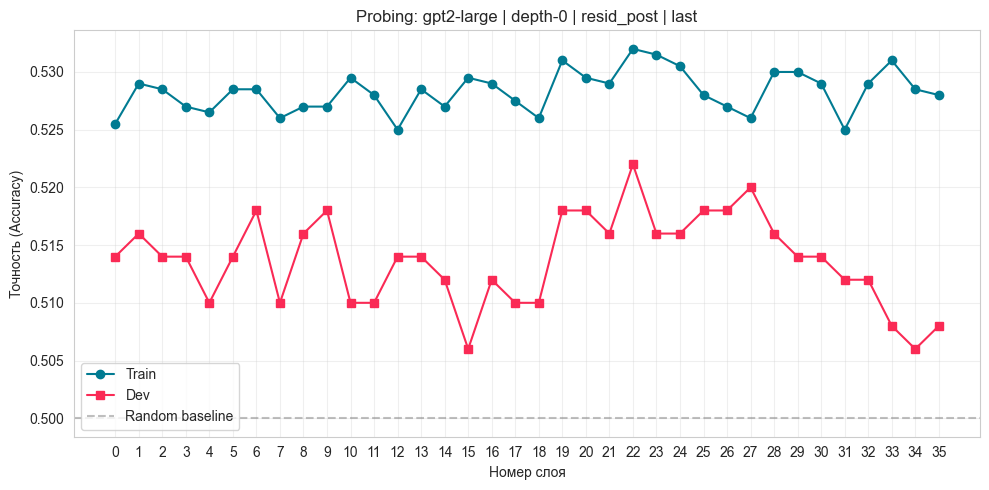

In [42]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

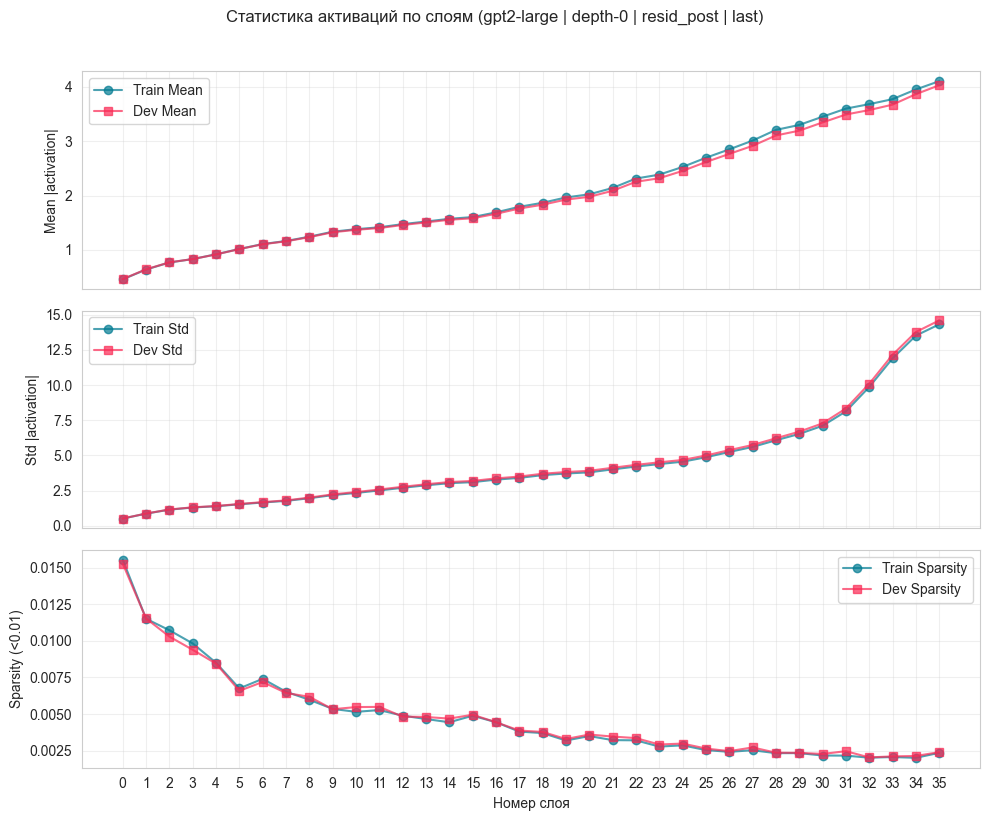

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [45]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large_depth-0_resid_post_last.json


### Проверка токенизации

In [46]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [47]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [48]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough....

Токены (первые 50): ['Anne', 'Ġis', 'Ġblue', '.', 'ĠAnne', 'Ġis', 'Ġrough', '.', 'ĠAnne', 'Ġis', 'Ġyoung', '.', 'ĠAll', 'Ġyoung', 'Ġpeople', 'Ġare', 'Ġcold', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġnice', 'Ġthen', 'Ġthey', 'Ġare', 'Ġgreen', '.', 'ĠRough', 'Ġpeople', 'Ġare', 'Ġyoung', '.', 'ĠIf', 'ĠAnne', 'Ġis', 'Ġgreen', 'Ġthen', 'ĠAnne', 'Ġis', 'Ġblue', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġfurry', 'Ġthen']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=True, в токенах=True
  'then': в тексте=True, в токенах=True
  'and': в тексте=True, в токенах=True
  'or': в тексте=False, в токенах=False
  'not': в тексте=False, в токенах=False
  'implies': в тексте=False, в токенах=F

In [49]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [50]:
data = load_probing_results(MODEL_SIZE, VARIANT, HOOK_NAME, POOLING)

In [51]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-05-15T17:08:51.373338',
  'variant': 'depth-0',
  'model_size': 'gpt2-large',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 8,
  'max_length': 184},
 'summary': {'best_layer': 22,
  'best_train_acc': 0.532,
  'best_dev_acc': 0.522,
  'n_layers': 36},
 'layers': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 'train_accs': [0.5255,
  0.529,
  0.5285,
  0.527,
  0.5265,
  0.5285,
  0.5285,
  0.526,
  0.527,
  0.527,
  0.5295,
  0.528,
  0.525,
  0.5285,
  0.527,
  0.5295,
  0.529,
  0.5275,
  0.526,
  0.531,
  0.5295,
  0.529,
  0.532,
  0.5315,
  0.5305,
  0.528,
  0.527,
  0.526,
  0.53,
  0.53,
  0.529,
  0.525,
  0.529,
  0.531,
  0.5285,
  0.528],
 'dev_accs': [0.514,
  0.516,
  0.514,
  0.514,
  0.51,
  0.514,
  0.518,
  0.51,

In [52]:
DIFF_LAYER = data["summary"]["best_layer"]

In [53]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [54]:
diff_stats = compute_differential_stats(
    model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [55]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0374
Стандартное отклонение разницы: 0.1085


In [57]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 440: 1.1125
  Нейрон 8: 0.8895
  Нейрон 792: 0.5312
  Нейрон 1061: 0.3095
  Нейрон 768: 0.2336
  Нейрон 22: 0.2316
  Нейрон 183: 0.1981
  Нейрон 89: 0.1794
  Нейрон 939: 0.1719
  Нейрон 248: 0.1694
  Нейрон 433: 0.1503
  Нейрон 870: 0.1500
  Нейрон 215: 0.1478
  Нейрон 735: 0.1329
  Нейрон 897: 0.1311
  Нейрон 485: 0.1188
  Нейрон 197: 0.1153
  Нейрон 448: 0.1134
  Нейрон 1095: 0.1071
  Нейрон 490: 0.1042
  Нейрон 705: 0.1042
  Нейрон 50: 0.1016
  Нейрон 131: 0.1008
  Нейрон 251: 0.0999
  Нейрон 590: 0.0998
  Нейрон 528: 0.0973
  Нейрон 1219: 0.0968
  Нейрон 750: 0.0968
  Нейрон 91: 0.0961
  Нейрон 71: 0.0960
  Нейрон 1213: 0.0950
  Нейрон 940: 0.0938
  Нейрон 1256: 0.0908
  Нейрон 143: 0.0889
  Нейрон 1035: 0.0884
  Нейрон 1087: 0.0875
  Нейрон 881: 0.0868
  Нейрон 54: 0.0863
  Нейрон 661: 0.0854
  Нейрон 778: 0.0853
  Нейрон 198: 0.0849
  Нейрон 1018: 0.0844
  Нейрон 211: 0.0834
  Нейрон 1014: 0.0832
  Нейрон 1208: 0.0829
  Ней

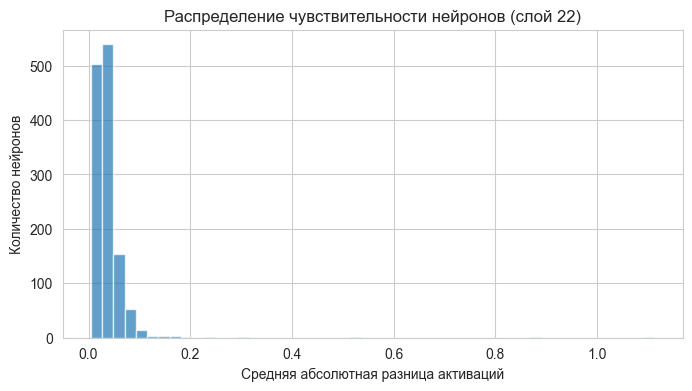

In [58]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [59]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large_depth-0_resid_post_last.json


In [60]:
top_texts, top_tokens = analyze_neuron_activations(
    model, tokenizer,
    layer_idx=22, neuron_idx=440,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [61]:
print("Топ-10 примеров для нейрона 440:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 440:
  [80.312] Charlie is furry. Charlie is quiet. Erin is nice. Erin is rough. Erin is smart. Fiona is furry. Fiona is nice. Quiet things are smart. If Charlie is furry then Charlie is white. Fiona is not furry.
  [80.062] Bob is round. Charlie is blue. Erin is round. Harry is red. Green, blue people are round. If someone is green and red then they are round. If Harry is blue then Harry is green. Harry is not red.
  [79.188] Charlie is furry. Charlie is quiet. Erin is nice. Erin is rough. Erin is smart. Fiona is furry. Fiona is nice. Quiet things are smart. If Charlie is furry then Charlie is white. Erin is white.
  [78.812] Erin is blue. Erin is smart. Erin is white. If something is blue then it is smart. All rough things are white. If something is white then it is blue. If Erin is blue then Erin is rough. If something is white and young then it is smart. If something is white and blue then it is green. Blue things are white. If something is young then it

In [62]:
print("Топ-30 токенов для нейрона 440:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 440:
urry: +94.719
iona: +85.396
in: +81.875
furry: +81.101
Anne: +80.616
The: +76.588
it: +74.276
is: +73.377
the: +73.209
Charlie: +73.202
Erin: +73.038
they: +72.904
not: +72.704
people: +72.584
Fiona: +72.212
are: +71.699
.: +71.532
F: +70.938
someone: +70.936
Bob: +70.439
tiger: +70.069
White: +70.000
Dave: +69.897
squirrel: +69.575
All: +69.512
quiet: +69.230
,: +69.216
bear: +68.417
Smart: +68.375
Rough: +68.125
